# Statevectors obtained on IQM

In [1]:
from py4lexis.session import LexisSession
from qaas.client import QProvider, QBackend, QJob


# 1. Authentication
lexis_session = LexisSession()
token = lexis_session.get_access_token()

# 2. Configure resources
PROJECT = "SURFq26"   # e.g. OPEN-37-1
RESOURCE = "VLQ-NL" # e.g. VLQ-CZ

# 3. Initialize QaaS
provider = QProvider(token, PROJECT)
backend:QBackend = provider.get_backend(RESOURCE)


/Users/renau001/Documents/projects/quantum/QuantumBayesianQuadrature/molqbq/.venv_vlq_qiskit145/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Welcome to the Py4LEXIS (v7.0.3)!
Proceeding login via login page...
Open provided url in your browser, please: https:/aai.lexis.tech/auth/realms/LEXIS_AAI_v2/protocol/openid-connect/auth/device?user_code=RYUA-UEKV
Check if user is logged in: Pending.                                            
Check if user is logged in: OK!
You have been successfully logged in LEXIS session.


# Create the encoding circuit

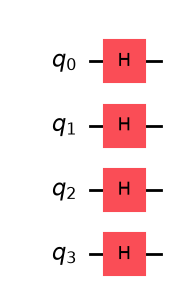

In [34]:
from qiskit import QuantumCircuit
import numpy as np 

qc = QuantumCircuit(4)
qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)

qc.draw('mpl')

# Transpile the circuit with VLQ

In [ ]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.primitives import BackendEstimatorV2


# transpile the circuit and observables
pm0 = generate_preset_pass_manager(backend=backend, optimization_level=0)
qc_transpiled_0 = pm0.run(qc)


# transpile the circuit and observables
pm1 = generate_preset_pass_manager(backend=backend, optimization_level=1)
qc_transpiled_1 = pm1.run(qc)





# Compute the Statevector of the transpiled circuit

In [36]:
from qiskit.quantum_info import Statevector

sv = Statevector.from_instruction(qc)
sv_vql_0 = Statevector.from_instruction(qc_transpiled_0)
sv_vql_1 = Statevector.from_instruction(qc_transpiled_1)

# Compare statevector

/Users/renau001/Documents/projects/quantum/QuantumBayesianQuadrature/molqbq/.venv_vlq_qiskit145/lib/python3.12/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/renau001/Documents/projects/quantum/QuantumBayesianQuadrature/molqbq/.venv_vlq_qiskit145/lib/python3.12/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/renau001/Documents/projects/quantum/QuantumBayesianQuadrature/molqbq/.venv_vlq_qiskit145/lib/python3.12/site-packages/matplotlib/transforms.py:844: ComplexWarning: Casting complex values to real discards the imaginary part
  bbox = Bbox(np.asarray(args, dtype=float).reshape((2, 2)))


/Users/renau001/Documents/projects/quantum/QuantumBayesianQuadrature/molqbq/.venv_vlq_qiskit145/lib/python3.12/site-packages/matplotlib/transforms.py:844: ComplexWarning: Casting complex values to real discards the imaginary part
  bbox = Bbox(np.asarray(args, dtype=float).reshape((2, 2)))


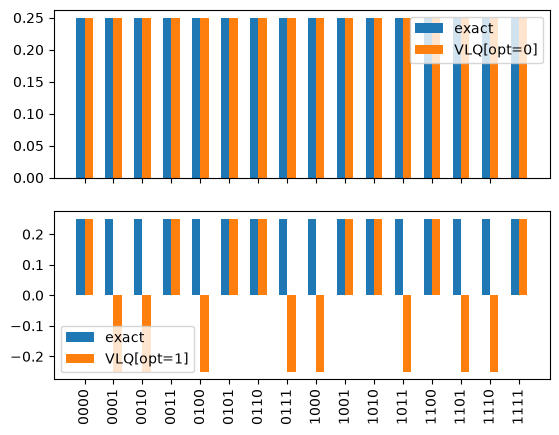

In [38]:
import matplotlib.pyplot as plt
import numpy as np 

xticks = [np.binary_repr(i, width=4) for i in range(16)]

plt.subplot(211)
plt.grouped_bar({'exact':sv, 'VLQ[opt=0]':sv_vql_0.data[:16]})
# plt.tick_params("x", rotation=90, rotation_mode="xtick")
plt.xticks(np.arange(15), [""]*15)
plt.legend()

plt.subplot(212)
plt.grouped_bar({'exact':sv, 'VLQ[opt=1]':sv_vql_1.data[:16]}, tick_labels=xticks, )
plt.tick_params("x", rotation=90, rotation_mode="xtick")
plt.legend()
